In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nicapotato/womens-ecommerce-clothing-reviews")

print("Path to dataset files:", path)

100%|██████████| 2.79M/2.79M [00:00<00:00, 98.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nicapotato/womens-ecommerce-clothing-reviews/versions/1


In [ ]:
import os
import pandas as pd

# List files in the downloaded path to find the CSV file
files = os.listdir(path)
print("Files in dataset directory:", files)

# Assuming the CSV file is named 'Womens Clothing E-Commerce Reviews.csv'
data_file = os.path.join(path, 'Womens Clothing E-Commerce Reviews.csv')

# Load the dataset
df = pd.read_csv(data_file, index_col=0)


Files in dataset directory: ['Womens Clothing E-Commerce Reviews.csv']


### Dataset Overview

Let's take a look at the first few rows of the dataset to understand its structure and content.

In [ ]:
# Display the first 5 rows of the DataFrame
display(df.head())

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


Now, let's get a concise summary of the DataFrame, including the data types and non-null values for each column.

In [ ]:
# Get information about the DataFrame (columns, non-null counts, dtypes)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB


And finally, some descriptive statistics for numerical columns.

In [ ]:
# Get descriptive statistics for numerical columns
display(df.describe())

,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,918.118709,43.198544,4.196032,0.822362,2.535936
std,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,18.000000,1.000000,0.000000,0.000000
25%,861.000000,34.000000,4.000000,1.000000,0.000000
50%,936.000000,41.000000,5.000000,1.000000,1.000000
75%,1078.000000,52.000000,5.000000,1.000000,3.000000
max,1205.000000,99.000000,5.000000,1.000000,122.000000


### Data Cleaning: Handling Missing Values

Let's address the missing values in our dataset. We'll start by checking the exact count of missing values per column.

In [ ]:
# Check for missing values
print("Missing values before handling:")
print(df.isnull().sum())

Missing values before handling:
Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64


Now, we will fill the missing values. For 'Title' and 'Review Text', we will replace NaN with an empty string. For 'Division Name', 'Department Name', and 'Class Name', we'll use 'Unknown'.

In [ ]:
# Fill missing 'Title' and 'Review Text' with empty strings
df['Title'].fillna('', inplace=True)
df['Review Text'].fillna('', inplace=True)

# Fill missing categorical names with 'Unknown'
df['Division Name'].fillna('Unknown', inplace=True)
df['Department Name'].fillna('Unknown', inplace=True)
df['Class Name'].fillna('Unknown', inplace=True)

print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64


### Data Cleaning: Handling Missing Values

Let's address the missing values in our dataset. We'll start by checking the exact count of missing values per column.

In [ ]:
# Check for missing values
print("Missing values before handling:")
print(df.isnull().sum())

Missing values before handling:
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64


Now, we will fill the missing values. For 'Title' and 'Review Text', we will replace NaN with an empty string. For 'Division Name', 'Department Name', and 'Class Name', we'll use 'Unknown'.

In [ ]:
# Fill missing 'Title' and 'Review Text' with empty strings
df['Title'] = df['Title'].fillna('')
df['Review Text'] = df['Review Text'].fillna('')

# Fill missing categorical names with 'Unknown'
df['Division Name'] = df['Division Name'].fillna('Unknown')
df['Department Name'] = df['Department Name'].fillna('Unknown')
df['Class Name'] = df['Class Name'].fillna('Unknown')

print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64


### Natural Language Processing (NLP): Text Preprocessing

Let's prepare our text data for NLP by combining 'Title' and 'Review Text' and performing cleaning steps like lowercasing, removing punctuation, and stop words.

In [ ]:
# Install and import necessary libraries for NLP
!pip install nltk
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# Download NLTK resources (if not already downloaded)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# Combine 'Title' and 'Review Text' into a new 'Full Text' column
df['Full Text'] = df['Title'] + ' ' + df['Review Text']

# Convert to lowercase
df['Full Text'] = df['Full Text'].str.lower()

# Remove punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))
df['Full Text'] = df['Full Text'].apply(remove_punctuation)

# Remove stop words
stop_words = set(stopwords.words('english'))
def remove_stopwords(text):
    word_tokens = word_tokenize(text)
    filtered_sentence = [w for w in word_tokens if not w in stop_words]
    return " ".join(filtered_sentence)
df['Full Text'] = df['Full Text'].apply(remove_stopwords)

# Display the first few processed texts
print("Original Review Text example:")
print(df['Review Text'].iloc[0])
print("\nProcessed Full Text example:")
print(df['Full Text'].iloc[0])

display(df[['Title', 'Review Text', 'Full Text']].head())

Original Review Text example:
Absolutely wonderful - silky and sexy and comfortable

Processed Full Text example:
absolutely wonderful silky sexy comfortable


,Title,Review Text,Full Text
0,,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky sexy comfortable
1,,Love this dress! it's sooo pretty. i happene...,love dress sooo pretty happened find store im ...
2,Some major design flaws,I had such high hopes for this dress and reall...,major design flaws high hopes dress really wan...
3,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",favorite buy love love love jumpsuit fun flirt...
4,Flattering shirt,This shirt is very flattering to all due to th...,flattering shirt shirt flattering due adjustab...


### Exploración de las Palabras Más Frecuentes

Vamos a identificar y visualizar las palabras más frecuentes en el texto completo procesado para entender los temas clave en las reseñas.

### Análisis de Sentimiento

Ahora, realizaremos un análisis de sentimiento en el texto completo procesado para entender la tonalidad emocional de las reseñas.

In [ ]:
# Install TextBlob if not already installed
!pip install textblob
from textblob import TextBlob

In [ ]:
# Function to get sentiment polarity and subjectivity
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity, analysis.sentiment.subjectivity

# Apply sentiment analysis to the 'Full Text' column
df[['Polarity', 'Subjectivity']] = df['Full Text'].apply(lambda text: pd.Series(get_sentiment(text)))

# Display the first few rows with sentiment scores
display(df[['Full Text', 'Polarity', 'Subjectivity']].head())

,Full Text,Polarity,Subjectivity
0,absolutely wonderful silky sexy comfortable,0.633333,0.933333
1,love dress sooo pretty happened find store im ...,0.318750,0.725000
2,major design flaws high hopes dress really wan...,0.081439,0.352567
3,favorite buy love love love jumpsuit fun flirt...,0.500000,0.678571
4,flattering shirt shirt flattering due adjustab...,0.458333,0.658333


### Distribución de la Polaridad del Sentimiento

Vamos a visualizar la distribución de los puntajes de polaridad para comprender el sentimiento general en las reseñas.

### Reseñas con la Polaridad Más Negativa

Identifiquemos las 5 reseñas con los puntajes de polaridad más bajos (más negativos).

In [ ]:
# Filter for reviews with negative polarity and sort by polarity in ascending order
most_negative_reviews = df[df['Polarity'] < 0].sort_values(by='Polarity', ascending=True)

# Display the top 5 most negative reviews
print("Top 5 Reviews with Most Negative Polarity:")
display(most_negative_reviews[['Full Text', 'Polarity', 'Review Text', 'Title']].head())

Top 5 Reviews with Most Negative Polarity:


,Full Text,Polarity,Review Text,Title
6296,yuck awful color horribly wrinkled messso disa...,-0.916667,"Awful color, horribly wrinkled and just a mess...",Yuck
14754,terrible quality cut cut design seems hems dis...,-0.875000,"Cut out design, no seems or hems.\r\n very dis...",Terrible quality cut
5114,save money disappointment price outrageous,-0.800000,"What a disappointment and for the price, it's ...",Save your money
10364,dont bother terribly unflattering wash looks d...,-0.800000,These are terribly unflattering the wash looks...,Don't bother
4908,disappointed wore bodysuit hole arm took,-0.750000,I wore this bodysuit once. it had a hole under...,So disappointed


### Reseñas con la Mayor Subjetividad

Identifiquemos las 5 reseñas con los puntajes de subjetividad más altos.

In [ ]:
# Sort by 'Subjectivity' in descending order to get the highest scores
most_subjective_reviews = df.sort_values(by='Subjectivity', ascending=False)

# Display the top 5 most subjective reviews
print("Top 5 Reviews with Highest Subjectivity:")
display(most_subjective_reviews[['Full Text', 'Polarity', 'Subjectivity', 'Review Text', 'Title']].head())

Top 5 Reviews with Highest Subjectivity:


,Full Text,Polarity,Subjectivity,Review Text,Title
11226,awesome ordered orange color perfect throwing ...,1.000000,1.0,I ordered the orange color too. these are perf...,Awesome!
7117,itchy beautiful sweater flattering stock photo...,0.850000,1.0,A beautiful sweater and very flattering on. t...,Very itchy!
3125,touch class got royal blueit absolutly beautiful,0.850000,1.0,I got this in the royal blue.it is absolutly b...,Touch of class
11524,nice addition fall wardrobe well fitted kinda ...,0.600000,1.0,Well fitted kinda slouchy sweater. matches pho...,Nice addition to my fall wardrobe
14895,sotra tank nice quality beautiful colors nice ...,0.683333,1.0,"Nice quality, beautiful colors. so nice i boug...",Sotra tank


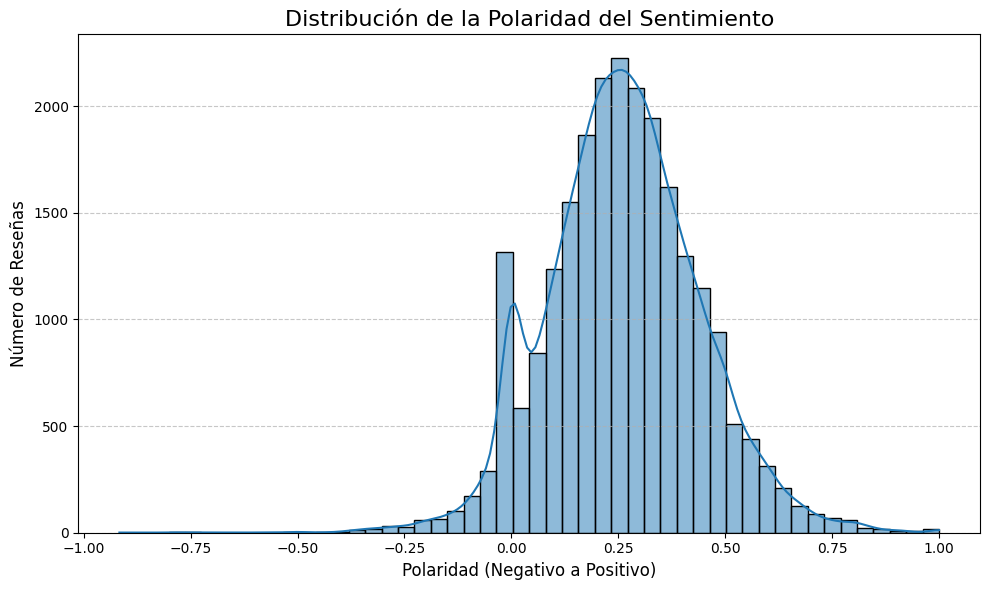

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Polarity'], bins=50, kde=True)
plt.title('Distribución de la Polaridad del Sentimiento', fontsize=16)
plt.xlabel('Polaridad (Negativo a Positivo)', fontsize=12)
plt.ylabel('Número de Reseñas', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

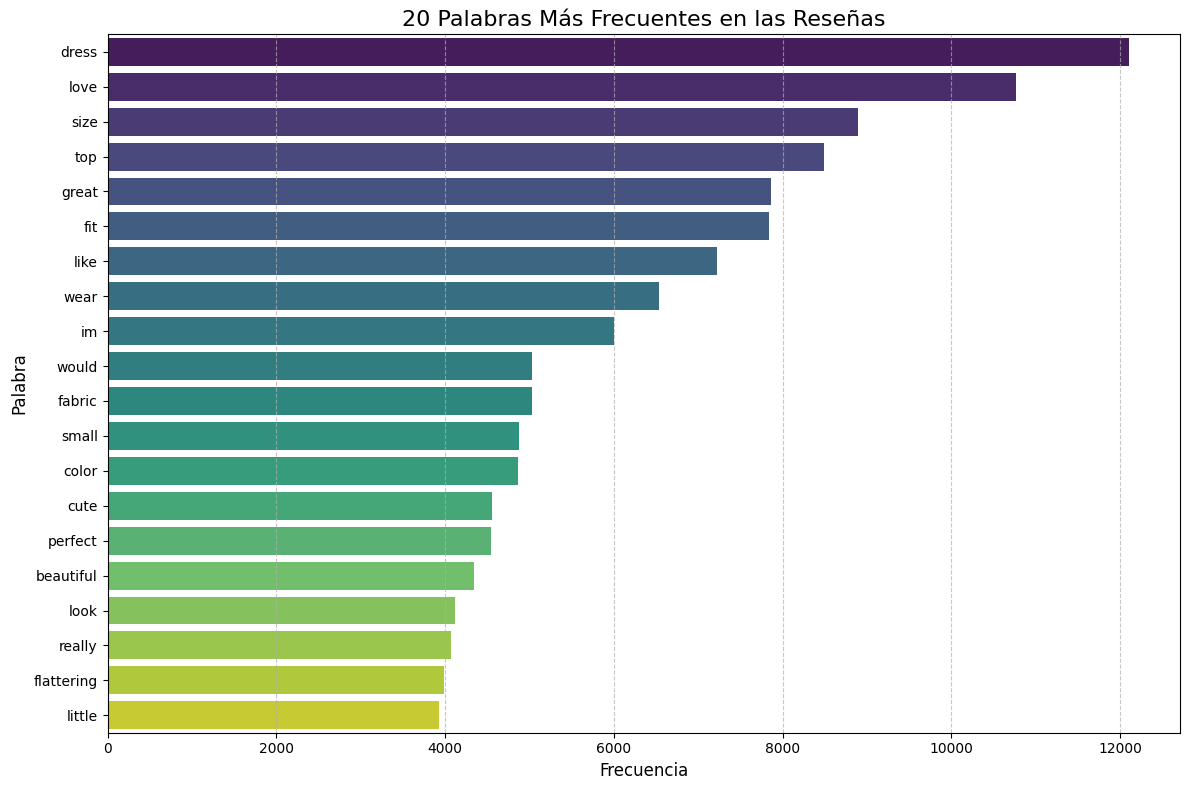

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Join all processed text into a single string
all_words = ' '.join(df['Full Text']).split()

# Count word frequencies
word_counts = Counter(all_words)

# Get the top 20 most common words
top_words = word_counts.most_common(20)

# Convert to DataFrame for easier plotting with seaborn
top_words_df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])

# Create the bar chart
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Word', data=top_words_df, palette='viridis', hue='Word', legend=False)
plt.title('20 Palabras Más Frecuentes en las Reseñas', fontsize=16)
plt.xlabel('Frecuencia', fontsize=12)
plt.ylabel('Palabra', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Gráfico de Dispersión: Polaridad vs. Subjetividad

Este gráfico de dispersión nos ayudará a visualizar la relación entre la polaridad (sentimiento positivo/negativo) y la subjetividad (grado de opinión) de las reseñas.

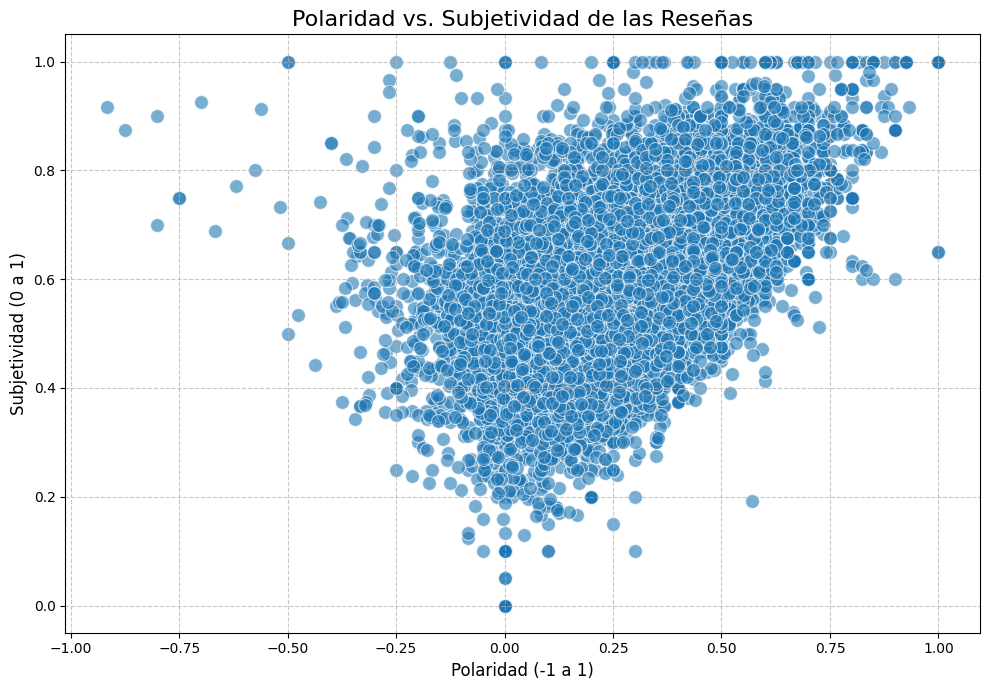

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Polarity', y='Subjectivity', data=df, alpha=0.6, s=100)
plt.title('Polaridad vs. Subjetividad de las Reseñas', fontsize=16)
plt.xlabel('Polaridad (-1 a 1)', fontsize=12)
plt.ylabel('Subjetividad (0 a 1)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Sentimiento Promedio por Departamento

Vamos a calcular la polaridad promedio para cada 'Department Name' para entender el sentimiento general de las reseñas por departamento.

In [ ]:
# Group by 'Department Name' and calculate the mean of 'Polarity'
department_sentiment = df.groupby('Department Name')['Polarity'].mean().reset_index()

# Sort for better readability
department_sentiment = department_sentiment.sort_values(by='Polarity', ascending=False)

print("Average Polarity by Department Name:")
display(department_sentiment)

Average Polarity by Department Name:


,Department Name,Polarity
1,Dresses,0.264652
0,Bottoms,0.264361
4,Tops,0.257842
2,Intimate,0.253371
3,Jackets,0.252188
6,Unknown,0.236879
5,Trend,0.230241


### Palabras Más Frecuentes en Reseñas del Departamento 'Trend'

Vamos a analizar el texto completo procesado de las reseñas del departamento 'Trend' para identificar las palabras más frecuentes y obtener una visión específica de los temas relevantes en esta categoría.

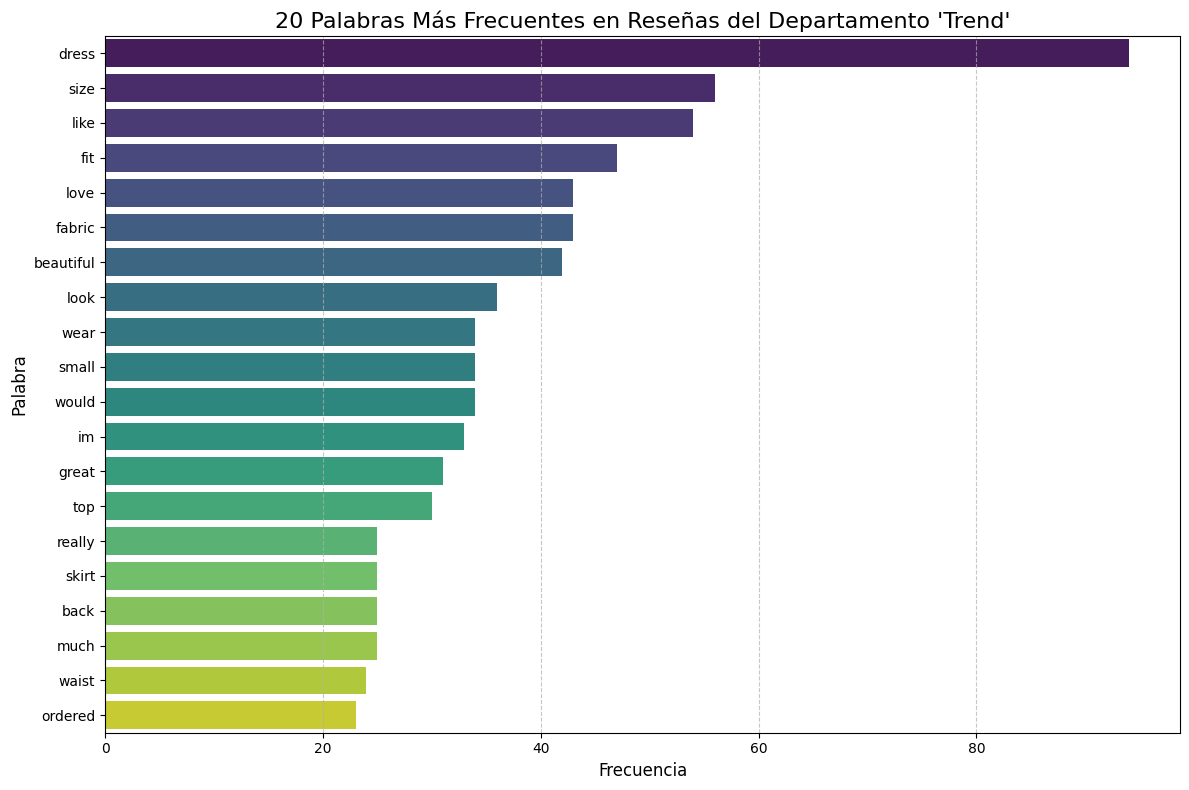

In [ ]:
# Filter DataFrame for 'Trend' department reviews
trend_reviews_df = df[df['Department Name'] == 'Trend']

# Join all processed text from 'Trend' reviews into a single string
all_trend_words = ' '.join(trend_reviews_df['Full Text']).split()

# Count word frequencies for 'Trend' reviews
trend_word_counts = Counter(all_trend_words)

# Get the top 20 most common words for 'Trend' department
top_trend_words = trend_word_counts.most_common(20)

# Convert to DataFrame for easier plotting with seaborn
top_trend_words_df = pd.DataFrame(top_trend_words, columns=['Word', 'Frequency'])

# Create the bar chart for 'Trend' department
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Word', data=top_trend_words_df, palette='viridis', hue='Word', legend=False)
plt.title('20 Palabras Más Frecuentes en Reseñas del Departamento \'Trend\'', fontsize=16)
plt.xlabel('Frecuencia', fontsize=12)
plt.ylabel('Palabra', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Install the wordcloud library if not already installed
!pip install wordcloud

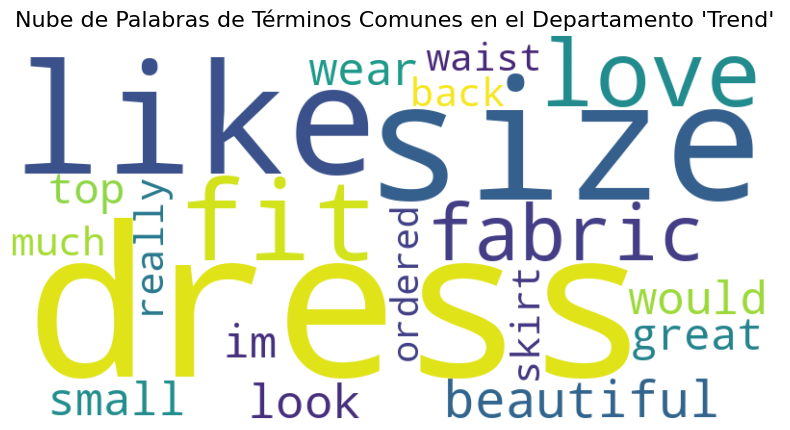

In [ ]:
from wordcloud import WordCloud

# Create a dictionary of word frequencies from the top_trend_words_df
# The WordCloud function expects a dictionary where keys are words and values are frequencies
word_freq_dict = dict(zip(top_trend_words_df['Word'], top_trend_words_df['Frequency']))

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq_dict)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de Términos Comunes en el Departamento \'Trend\'', fontsize=16)
plt.show()

### Nube de Palabras para el Conjunto de Datos Completo

Vamos a generar una nube de palabras a partir de todos los términos procesados en el conjunto de datos para identificar visualmente las palabras más frecuentes y sus temas generales.

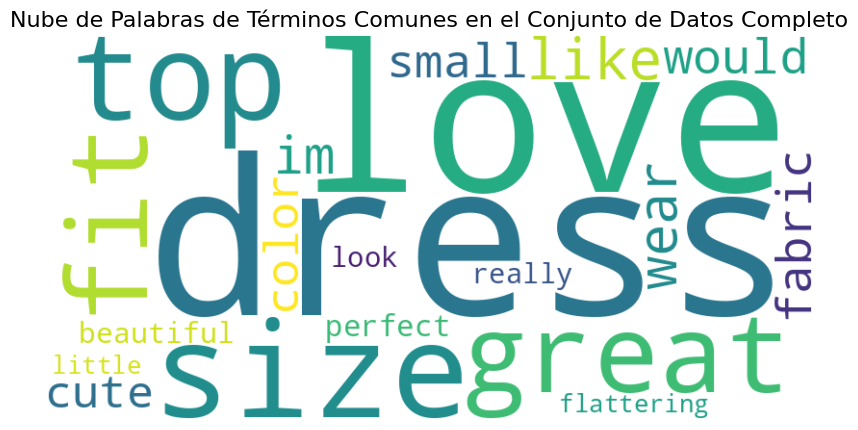

In [ ]:
from wordcloud import WordCloud

# Create a dictionary of word frequencies from the top_words_df (for the entire dataset)
# The WordCloud function expects a dictionary where keys are words and values are frequencies
all_word_freq_dict = dict(zip(top_words_df['Word'], top_words_df['Frequency']))

# Generate the word cloud for the entire dataset
wordcloud_all = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(all_word_freq_dict)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de Términos Comunes en el Conjunto de Datos Completo', fontsize=16)
plt.show()